# Vehicle Claim Analysis
This notebook analyzes insurance claims by vehicle make and model. It includes:
- Total claim amount by vehicle
- Average claim per policy by vehicle
- Visual identification of high- and low-risk models

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset
df = pd.read_csv("../data/insurance_data.txt", sep='|')

# Ensure claims columns are numeric
df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')
df = df.dropna(subset=['TotalClaims'])

C:\Users\USED\AppData\Local\Temp\ipykernel_29500\1670509580.py:9: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data.txt", sep='|')


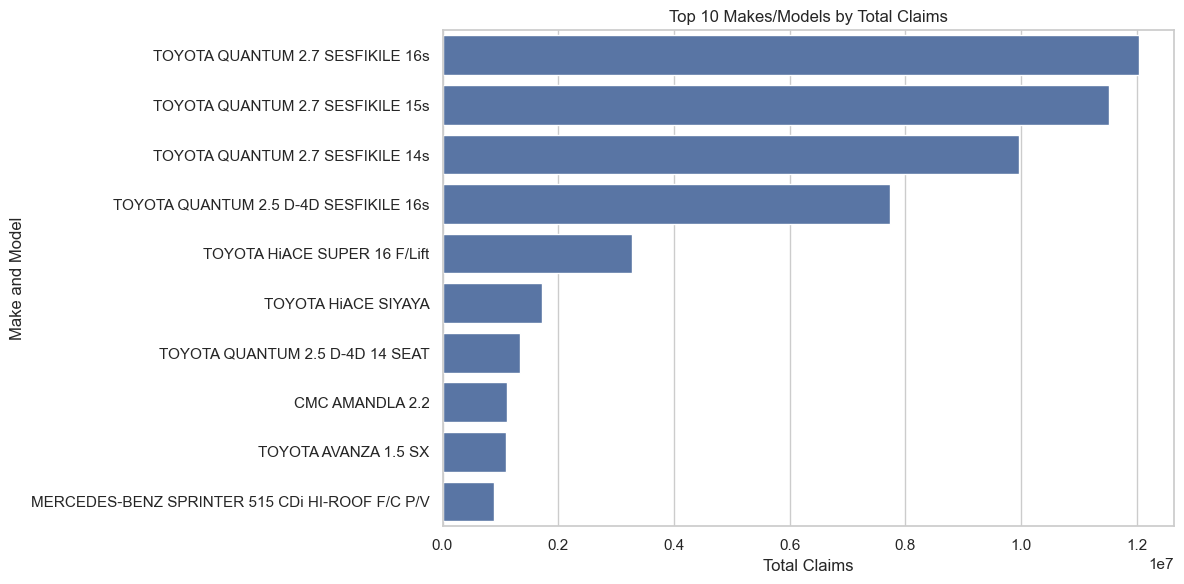

In [3]:
# Total Claims by Make/Model
total_claims = df.groupby(['make', 'Model'])['TotalClaims'].sum().reset_index()
top_total = total_claims.sort_values(by='TotalClaims', ascending=False).head(10)

sns.barplot(data=top_total, x='TotalClaims', y=top_total['make'] + " " + top_total['Model'])
plt.title("Top 10 Makes/Models by Total Claims")
plt.xlabel("Total Claims")
plt.ylabel("Make and Model")
plt.tight_layout()
plt.savefig("../outputs/top_10_claims_by_vehicle.png")
plt.show()

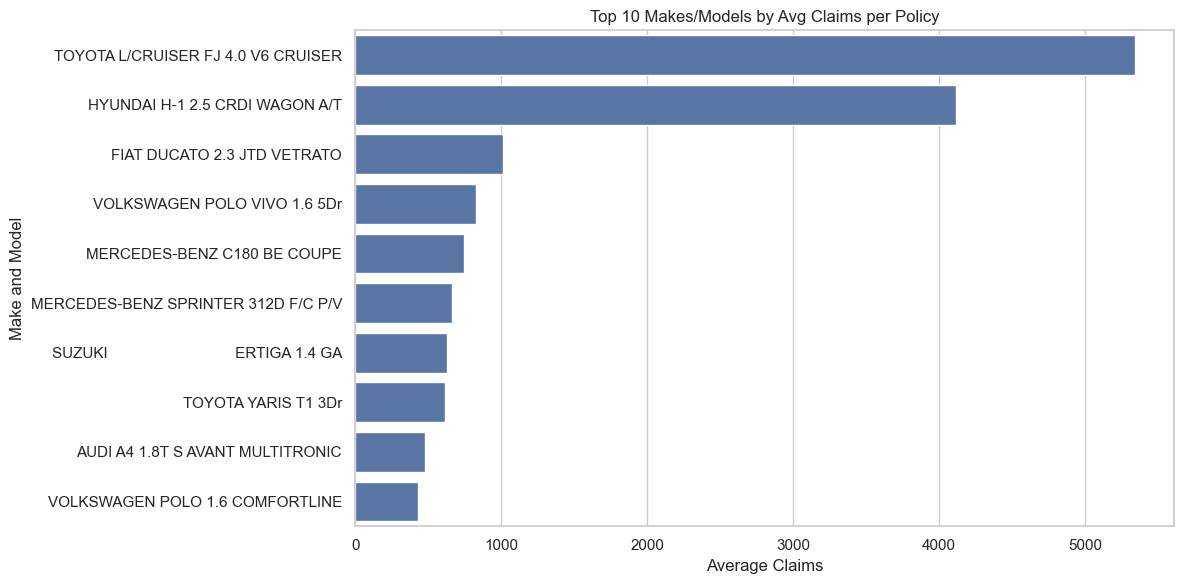

In [4]:
# Average Claims by Make/Model
model_counts = df.groupby(['make', 'Model']).size().reset_index(name='count')
avg_claims = df.groupby(['make', 'Model'])['TotalClaims'].mean().reset_index()
avg_claims = avg_claims.merge(model_counts, on=['make', 'Model'])
avg_claims = avg_claims[avg_claims['count'] >= 20]
avg_claims = avg_claims.rename(columns={'TotalClaims': 'AvgTotalClaims'})

top_avg = avg_claims.sort_values(by='AvgTotalClaims', ascending=False).head(10)

sns.barplot(data=top_avg, x='AvgTotalClaims', y=top_avg['make'] + " " + top_avg['Model'])
plt.title("Top 10 Makes/Models by Avg Claims per Policy")
plt.xlabel("Average Claims")
plt.ylabel("Make and Model")
plt.tight_layout()
plt.savefig("../outputs/top_10_avg_claims_by_vehicle.png")
plt.show()

### Key Findings:
- The highest total claims are concentrated in specific vehicle makes/models.
- When normalized per policy, some less common vehicles show higher average claim risk.
- This insight supports targeted pricing or policy adjustments by vehicle type.